In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
np.random.seed(1)

#### Learning Curves and Random-Effects Models

In [3]:
# Simulation parameters

n_participants = 30

n_sessions = 8

grand_intercept = 700

population_slope = -20

intercept_sd = 60

slope_sd = 6

trial_sd = 20

In [4]:
# Simulating participant-specific effects.

participant_intercepts = np.random.normal(
    loc=grand_intercept,
    scale=intercept_sd,
    size=n_participants
)

participant_slopes = np.random.normal(
    loc=population_slope,
    scale=slope_sd,
    size=n_participants
)

In [5]:
# Simulating repeated observations.

participant = []

session = []

reaction_time = []

for i in range(n_participants):

    for s in range(1, n_sessions + 1):

        rt = np.random.normal(
            loc=participant_intercepts[i] +
                participant_slopes[i] * s,
            scale=trial_sd
        )

        participant.append(i + 1)

        session.append(s)

        reaction_time.append(rt)

data = pd.DataFrame({
    "participant": participant,
    "session": session,
    "reaction_time": reaction_time
})

In [6]:
# Random Intercept Model

random_intercept_model = smf.mixedlm(
    "reaction_time ~ session",
    data=data,
    groups=data["participant"]
).fit()

In [7]:
# Random Slope Model

random_slope_model = smf.mixedlm(
    "reaction_time ~ session",
    data=data,
    groups=np.ones(len(data)),
    re_formula="~session"
).fit()

C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [8]:
# Random Intercept + Random Slope Model

random_intercept_slope_model = smf.mixedlm(
    "reaction_time ~ session",
    data=data,
    groups=data["participant"],
    re_formula="~session"
).fit()

# Predictions

data["predicted"] = random_intercept_slope_model.fittedvalues

C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
C:\Users\Erfan\miniforge3\envs\cog-modeling\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood o

Note: The random slope-only model is included for learning purposes to illustrate random slopes; in real research, random intercept and random slope models are usually preferred because they better represent repeated-measures data and are generally more stable to estimate.

In [9]:
# Summary statistics

print("Dataset\n", data.head())

print("\nNumber of participants:", data["participant"].nunique())

print("\nSessions per participant:", n_sessions)

print("\nRandom intercept model\n")

print(random_intercept_model.summary())

print("\nRandom slope model\n")

print(random_slope_model.summary())

print("\nRandom intercept + random slope model\n")

print(random_intercept_slope_model.summary())

Dataset
    participant  session  reaction_time   predicted
0            1        1     758.222798  763.786214
1            1        2     774.218156  744.597974
2            1        3     735.269425  725.409734
3            1        4     694.899007  706.221495
4            1        5     686.481262  687.033255

Number of participants: 30

Sessions per participant: 8

Random intercept model

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reaction_time
No. Observations: 240     Method:             REML         
No. Groups:       30      Scale:              500.1322     
Min. group size:  8       Log-Likelihood:     -1143.2017   
Max. group size:  8       Converged:          Yes          
Mean group size:  8.0                                      
-----------------------------------------------------------
             Coef.   Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    6

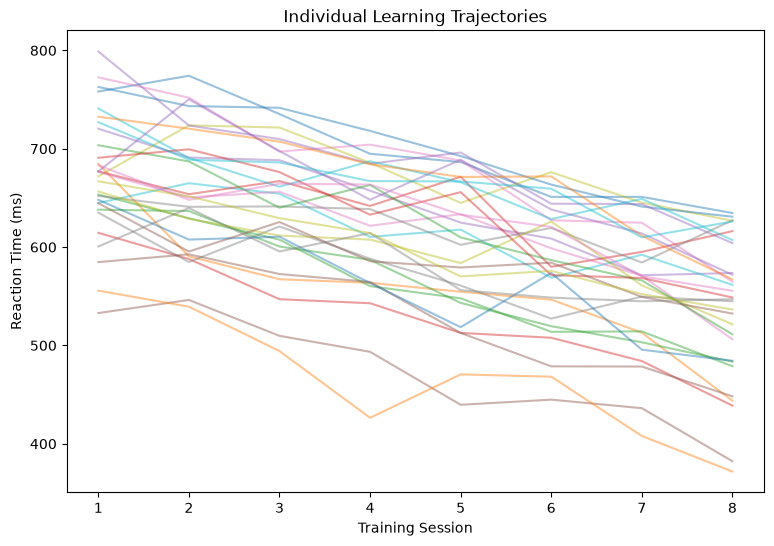

In [10]:
# Visualization

plt.figure(figsize=(9, 6))

for participant_id in data["participant"].unique():

    participant_data = data[
        data["participant"] == participant_id
    ]

    plt.plot(
        participant_data["session"],
        participant_data["reaction_time"],
        alpha=0.45
    )

plt.xlabel("Training Session")
plt.ylabel("Reaction Time (ms)")
plt.title("Individual Learning Trajectories")

plt.show()